# SPINN × 时变 Ornstein–Uhlenbeck 过程：快速复现与评估

本 notebook 在**不修改仓库代码**的前提下，直接调用仓库中的 SPINN 网络（`model/JumpSDEsTrans.py` 中的 `JumpSDEsTransformer`）和训练流程（`TrainJumpSDEsTransform.py` 中的 `train` / `train_sigma` / `train_velocity` / `transform`），完成：

1. **数据模拟**：不再使用 AnDi 反常扩散数据集，而是模拟参数随时间变化的 OU 过程；
2. **网络训练**：按照 `run_SPINN.py` 的三阶段流程（主网络 → 扩散网络 → 漂移网络）训练；
3. **结果评估**：把网络给出的漂移项、扩散项与模拟真值逐帧对比，并与一个经典的滑动窗口 OLS 基线比较。

模拟的随机微分方程为

$$
\mathrm{d}X_t = \theta_t\,(\mu - X_t)\,\mathrm{d}t + \sigma_t\,\mathrm{d}W_t ,
$$

其中均值回复速率 $\theta_t$ 与噪声强度 $\sigma_t$ 都随时间变化，我们设计了 6 种组合。

> 运行方式：把本 notebook 放在仓库根目录（与 `run_SPINN.py` 同级）下，从上到下依次运行。`QUICK = True` 时在 4 核 CPU 上全部运行约 10 分钟；有 GPU 会快很多。

## 0. 环境准备

- 自动定位仓库根目录并加入 `sys.path`；
- 仓库中的 `robust_loss_pytorch/distribution.py` 依赖 `pkg_resources`，新版 `setuptools` 已移除该模块，这里提供一个等价的兼容垫片（只实现用到的 `resource_stream`），不改动仓库源码；
- 依赖：`torch numpy pandas matplotlib scikit-learn scipy mpmath torch_dct`。

In [1]:
import os, sys, re, glob, time, types, shutil, argparse, warnings
warnings.filterwarnings('ignore')

# 定位仓库根目录（包含 TrainJumpSDEsTransform.py 的目录）
REPO_ROOT = os.path.abspath('.')
while not os.path.exists(os.path.join(REPO_ROOT, 'TrainJumpSDEsTransform.py')):
    parent = os.path.dirname(REPO_ROOT)
    if parent == REPO_ROOT:
        raise FileNotFoundError('请把 notebook 放在 SPINN 仓库内运行')
    REPO_ROOT = parent
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# pkg_resources 兼容垫片
try:
    import pkg_resources  # noqa: F401
except ImportError:
    _shim = types.ModuleType('pkg_resources')
    def _resource_stream(package, resource):
        base = os.path.dirname(sys.modules[package].__file__)
        return open(os.path.join(base, resource), 'rb')
    _shim.resource_stream = _resource_stream
    sys.modules['pkg_resources'] = _shim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import ConcatDataset
from scipy.ndimage import uniform_filter1d

# —— 仓库代码 ——
from model.JumpSDEsTrans import JumpSDEsTransformer
from TrainJumpSDEsTransform import (DatasetTracks, generate_dataset_torch, train, train_sigma,
                                    train_velocity, transform)
from utils.csv2npy import v_normalize_batch_encoder

torch.set_num_threads(os.cpu_count())
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('repo :', REPO_ROOT)
print('torch:', torch.__version__, '| device:', DEVICE, '| threads:', torch.get_num_threads())

# 统一绘图风格
C_TRUE, C_SPINN, C_BASE = '#3a3a38', '#2a78d6', '#eb6834'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 1.6,
                     'font.size': 9, 'legend.frameon': False})
plt.rcParams['axes.unicode_minus'] = False

repo : /home/user/SPINN
torch: 2.14.0+cu130 | device: cpu | threads: 4


## 1. 配置

配置项与 `run_SPINN.py` 的命令行参数一一对应（用 `argparse.Namespace` 构造，仓库函数可直接使用）。

- `QUICK = True`：网络结构不变，只缩小宽度（`d_model/hidden/h_dim` 减半、Transformer 2 层）并减少 epoch，用于快速跑通；
- `QUICK = False`：使用 `run_SPINN.py` 的默认超参数（100 + 50 epoch），耗时较长，建议在 GPU 上运行。

仓库的学习率调度器是 Transformer 式的 warmup：

$$
\mathrm{lr}(s) = \mathrm{scale}\cdot d_{\text{model}}^{-1/2}\cdot\min\!\left(s^{-1/2},\; s\cdot s_{\text{warmup}}^{-3/2}\right),
$$

默认 `warmup_steps=2000` 是为大数据集设计的，小数据快速训练时 lr 还没升起来训练就结束了，所以这里按总步数自动设置 warmup。

In [2]:
QUICK = True
SEED = 0

cfg = argparse.Namespace(
    # 训练
    epochs=100, epochs_VDt=50, batch_size=20, lr=1e-3, seed=SEED, clip_grad=5.0,
    scale=0.375, warmup_steps=2000, RESUME=False,
    # 网络
    default_enc_nn=((128, 'gelu'), (128, 'gelu')), hidden_size=128, layers=2, h_dim=64,
    d_model=128, n_heads=8, enc_layers=3, dropout=0.25, is_var_head=True,
    in_dim=2, out_dim=2, pred_length=50, encoder_length=50,
    # 损失权重
    beta_ac=0.5, beta_weight=0.5, beta_observe=0.0, beta_conti=0.0,
    # 数据
    noise_adding=0.0, sample_rates=1.0, sample_nums=0,
    # 输出
    dload='./model_dir/ou_demo', save_name='ou-demo', model_name='ou-demo.pth',
    device=DEVICE,
)
if QUICK:
    cfg.epochs, cfg.epochs_VDt = 12, 6
    cfg.default_enc_nn = ((64, 'gelu'), (64, 'gelu'))
    cfg.hidden_size, cfg.h_dim, cfg.d_model, cfg.n_heads, cfg.enc_layers = 64, 32, 64, 4, 2

# 清理上一次运行留下的模型/缓存，保证可重复
shutil.rmtree(cfg.dload, ignore_errors=True)
os.makedirs(cfg.dload, exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)
L_ENC, L_PRED = cfg.encoder_length, cfg.pred_length
WIN = L_ENC + L_PRED  # 每个片段长度 = 编码头 + 预测段

## 2. 时变 OU 过程的数据模拟

### 2.1 精确离散化

在每个采样间隔 $[t_n, t_n+\Delta]$ 内把 $\theta_t,\sigma_t$ 视为常数 $\theta_n,\sigma_n$，OU 过程有精确的转移分布（无 Euler 离散误差）：

$$
X_{n+1} = \mu + (X_n-\mu)\,e^{-\theta_n\Delta} + \sigma_n\sqrt{\frac{1-e^{-2\theta_n\Delta}}{2\theta_n}}\;\xi_n,\qquad \xi_n\sim\mathcal N(0,1).
$$

因此每一帧都有**解析真值**，这正是 SPINN 要估计的两个量：

$$
\underbrace{\mathbb E[X_{n+1}-X_n\mid X_n]}_{\text{单步漂移位移}} = (\mu-X_n)\left(1-e^{-\theta_n\Delta}\right)\approx \theta_n(\mu-X_n)\Delta ,
$$

$$
\underbrace{\mathrm{Var}[X_{n+1}\mid X_n]}_{\text{单步扩散方差}} = \sigma_n^2\,\frac{1-e^{-2\theta_n\Delta}}{2\theta_n}\approx \sigma_n^2\Delta .
$$

为了方便和 $\sigma_t$ 对照，定义有效噪声强度 $\sigma^{\mathrm{eff}}_n=\sqrt{\mathrm{Var}[X_{n+1}\mid X_n]/\Delta}$，它在 $\theta\Delta\ll1$ 时等于 $\sigma_n$。

与 SPINN 处理的二维单粒子轨迹一致，我们模拟二维轨迹，$x,y$ 两个方向是独立、同参数的 OU 过程，平衡位置 $\mu=(2,-1)$。初始值从 $t=0$ 时刻的平稳分布 $\mathcal N\big(\mu,\sigma_0^2/(2\theta_0)\big)$ 中抽取。

In [3]:
DT = 0.02                 # 采样间隔 Δ
T_LEN = 1000              # 每条轨迹帧数（需为 WIN 的整数倍）
N_TRAIN, N_TEST = 12, 16  # 每个情景的训练 / 测试轨迹数
MU = np.array([2.0, -1.0])
t_grid = np.arange(T_LEN) * DT
T_END = t_grid[-1] + DT

def square_wave(t, period):
    return (np.floor(t / (period / 2)) % 2).astype(float)  # 0,1,0,1,...

SCENARIOS = {
    'A 常数基准':       dict(en='A: constant θ, σ',
                            theta=lambda t: 4.0 + 0 * t,
                            sigma=lambda t: 1.0 + 0 * t),
    'B σ 阶跃':         dict(en='B: σ step',
                            theta=lambda t: 4.0 + 0 * t,
                            sigma=lambda t: np.where(t < T_END / 2, 0.6, 1.5)),
    'C σ 正弦':         dict(en='C: σ sine',
                            theta=lambda t: 4.0 + 0 * t,
                            sigma=lambda t: 1.0 + 0.5 * np.sin(2 * np.pi * t / 10)),
    'D θ 线性增加':     dict(en='D: θ ramp',
                            theta=lambda t: 1.0 + 9.0 * t / T_END,
                            sigma=lambda t: 1.0 + 0 * t),
    'E θ 正弦 + σ 线性': dict(en='E: θ sine + σ ramp',
                            theta=lambda t: 5.0 + 3.0 * np.sin(2 * np.pi * t / 8),
                            sigma=lambda t: 0.5 + 1.0 * t / T_END),
    'F θ/σ 反相切换':    dict(en='F: θ/σ anti-phase switch',
                            theta=lambda t: 2.0 + 6.0 * square_wave(t, 10),
                            sigma=lambda t: 1.4 - 0.7 * square_wave(t, 10)),
}

def simulate_ou(theta_fn, sigma_fn, n_tracks, rng):
    """精确离散化模拟二维时变 OU 过程，返回轨迹及逐帧真值"""
    th, sg = theta_fn(t_grid), sigma_fn(t_grid)
    a = np.exp(-th * DT)                                   # (T,)
    sd = sg * np.sqrt((1 - a ** 2) / (2 * th))             # 单步条件标准差
    X = np.empty((n_tracks, T_LEN, 2))
    X[:, 0] = MU + sg[0] / np.sqrt(2 * th[0]) * rng.standard_normal((n_tracks, 2))
    for n in range(T_LEN - 1):
        X[:, n + 1] = MU + (X[:, n] - MU) * a[n] + sd[n] * rng.standard_normal((n_tracks, 2))
    drift = (MU - X) * (1 - a)[None, :, None]               # 单步漂移位移真值 (N,T,2)
    var = np.broadcast_to((sd ** 2)[None, :, None], X.shape).copy()  # 单步方差真值
    return dict(X=X, drift=drift, var=var, theta=th, sigma=sg, sigma_eff=sd / np.sqrt(DT))

rng = np.random.default_rng(SEED)
DATA = {}
for name, sc in SCENARIOS.items():
    DATA[name] = dict(train=simulate_ou(sc['theta'], sc['sigma'], N_TRAIN, rng),
                      test=simulate_ou(sc['theta'], sc['sigma'], N_TEST, rng))
EN = {k: v['en'] for k, v in SCENARIOS.items()}   # 图中使用英文标题，避免缺少中文字体时显示方框
print({k: v['train']['X'].shape for k, v in DATA.items()})

{'A 常数基准': (12, 1000, 2), 'B σ 阶跃': (12, 1000, 2), 'C σ 正弦': (12, 1000, 2), 'D θ 线性增加': (12, 1000, 2), 'E θ 正弦 + σ 线性': (12, 1000, 2), 'F θ/σ 反相切换': (12, 1000, 2)}


### 2.2 参数日程与样例轨迹

上排是每个情景下 $\theta_t$（左轴）与 $\sigma_t$ 的设计，下排是一条样例轨迹的 $x$ 分量。

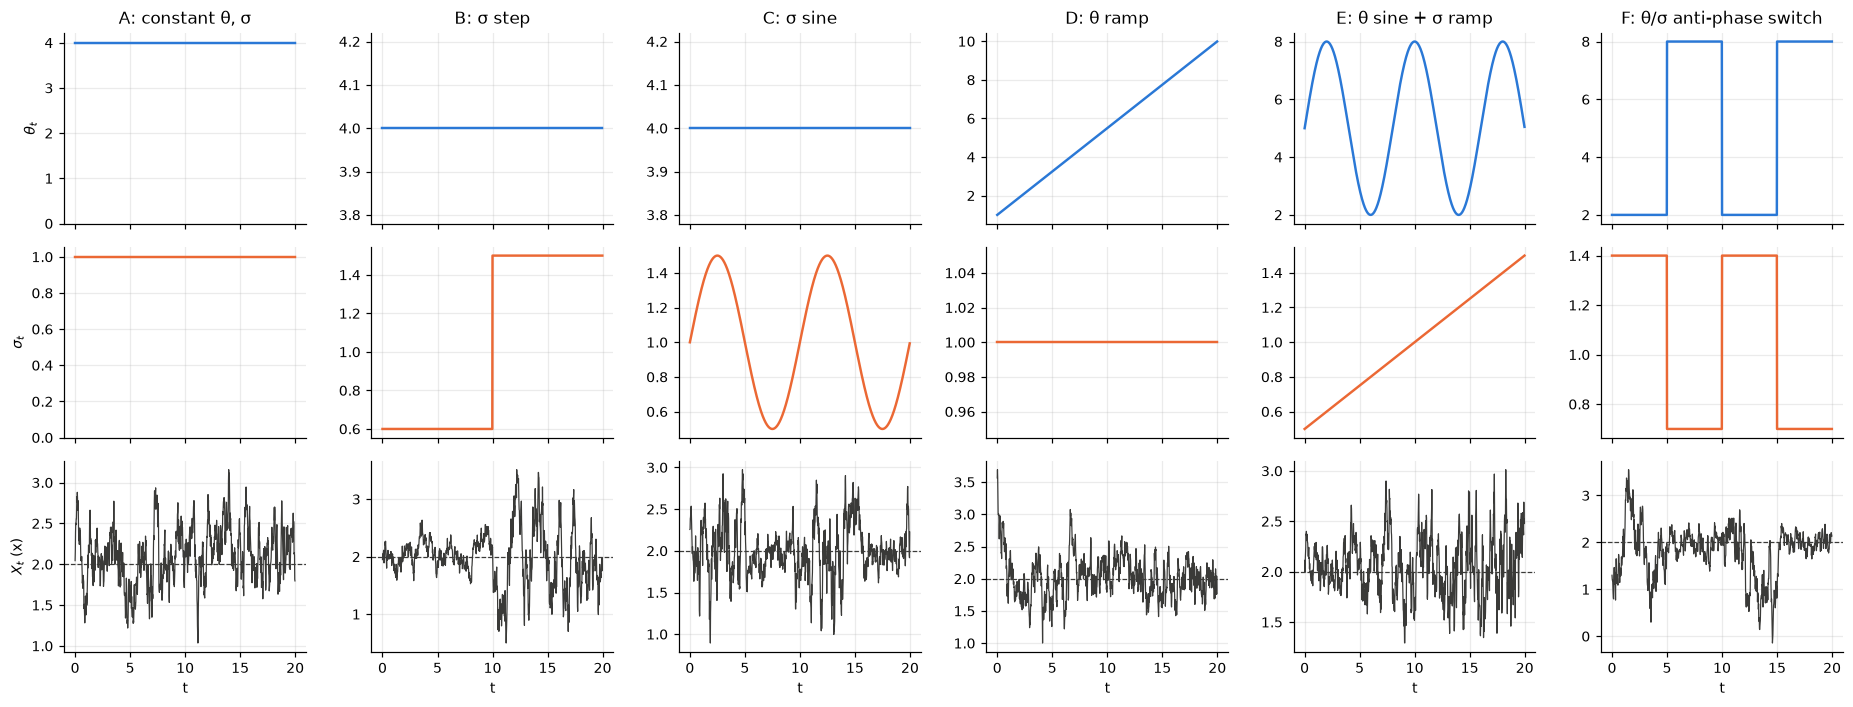

In [4]:
names = list(SCENARIOS)
fig, axes = plt.subplots(3, 6, figsize=(17, 6.5), sharex=True)
for j, name in enumerate(names):
    d = DATA[name]['train']
    axes[0, j].plot(t_grid, d['theta'], color=C_SPINN)
    axes[0, j].set_title(EN[name])
    axes[1, j].plot(t_grid, d['sigma'], color=C_BASE)
    axes[2, j].plot(t_grid, d['X'][0, :, 0], color=C_TRUE, lw=0.8)
    axes[2, j].axhline(MU[0], color=C_TRUE, ls='--', lw=0.8)
    axes[2, j].set_xlabel('t')
axes[0, 0].set_ylabel(r'$\theta_t$'); axes[1, 0].set_ylabel(r'$\sigma_t$'); axes[2, 0].set_ylabel(r'$X_t$ (x)')
axes[0, 0].set_ylim(bottom=0); axes[1, 0].set_ylim(bottom=0)
fig.tight_layout(); plt.show()

## 3. 按仓库格式切分与归一化

与 `utils/csv2npy.py::process_and_save_tracks` 完全一致：

- **regular tracks**：窗口长度 $L=L_{\text{enc}}+L_{\text{pred}}=100$，步长 100 不重叠地切片；
- **head tracks**：先在轨迹前面补 $L_{\text{pred}}$ 个初始点，再同样切片，使每一帧都落在某个窗口的预测段内；
- **归一化**：调用仓库的 `v_normalize_batch_encoder`，以同一“文件”内所有片段的步长均方根为单位（每个维度一个尺度 $s_d$），输出位移被缩放为单位量级：

$$
\tilde x_{k} = \sum_{j<k}\frac{x_{j+1}-x_j}{s_d},\qquad s_d = \sqrt{\big\langle (\Delta x_d)^2\big\rangle}.
$$

反归一化时：漂移 $\times s_d$，方差 $\times s_d^2$（与 `utils/export_results.py` 相同）。

这里把“一个情景的 train 或 test 集 × (regular / head)”视为仓库里的一个 csv 文件。另外 `DatasetTracks` 会把每个片段减去编码段最后一个点 $x_{L_{\text{enc}}-1}$，所以**网络只看到相对位移**，平衡位置 $\mu$ 必须从历史轨迹中隐式推断——这对 OU 这种依赖绝对位置的漂移是一个真实的挑战。

In [5]:
def segment(arr, is_head=False):
    """(N,T,...) -> (N*nW, WIN, ...)，与 csv2npy.prepare_trajectory_segments 相同的切片方式"""
    if is_head:
        pad = np.repeat(arr[:, :1], L_PRED, axis=1)
        arr = np.concatenate([pad, arr[:, :-L_PRED]], axis=1)
    starts = np.arange(0, arr.shape[1] - WIN + 1, WIN)
    return np.concatenate([arr[:, s:s + WIN][:, None] for s in starts], axis=1).reshape(-1, WIN, *arr.shape[2:])

def build_segments(sim):
    N = sim['X'].shape[0]
    frame = np.broadcast_to(np.arange(T_LEN), (N, T_LEN))
    track = np.broadcast_to(np.arange(N)[:, None], (N, T_LEN))
    out = {}
    for kind, head in [('regular', False), ('head', True)]:
        seg = segment(sim['X'], head)
        seg_norm, s = v_normalize_batch_encoder(seg, encoder_len=L_ENC)   # 仓库函数
        out[kind] = dict(x=seg_norm.astype(np.float32), norm=s,
                         frame=segment(frame, head), track=segment(track, head))
    return out

SEGS = {name: {split: build_segments(DATA[name][split]) for split in ['train', 'test']} for name in names}
ex = SEGS[names[0]]['train']
print('regular 片段:', ex['regular']['x'].shape, '| head 片段:', ex['head']['x'].shape,
      '| 归一化尺度 s_d =', np.round(ex['regular']['norm'], 4))

# 检查：regular + head 的预测段恰好覆盖每条轨迹的全部帧
cov = np.zeros((N_TRAIN, T_LEN), int)
for kind in ['regular', 'head']:
    f, tr = ex[kind]['frame'][:, L_ENC:], ex[kind]['track'][:, L_ENC:]
    np.add.at(cov, (tr, f), 1)
assert (cov == 1).all(), '帧覆盖不完整'
print('帧覆盖检查通过：每帧恰好被一个预测段覆盖')

regular 片段: (120, 100, 2) | head 片段: (120, 100, 2) | 归一化尺度 s_d = [0.1374 0.1382]
帧覆盖检查通过：每帧恰好被一个预测段覆盖


## 4. SPINN 网络（来自仓库）

`JumpSDEsTransformer` 的结构：

1. **Transformer 编码器**（带因果 mask）读取整段（编码头 + 预测段）得到历史表示 $h^{x}_t$；
2. 残差 FFNN 嵌入当前观测 $h_0=\mathrm{FFNN}(x_t)+h^{x}_t$；
3. **GRU 解码器**给出两个输出：重构 $y^{(0)}_t\approx x_t$ 与一步预测 $y^{(1)}_t\approx \mathbb E[x_{t+1}\mid x_{\le t}]$。

由此定义原始漂移与原始扩散：

$$
v^{\text{raw}}_t = y^{(1)}_t - x_t,\qquad s^{\text{raw}}_t = \big(x_{t+1}-y^{(1)}_t\big)^2 .
$$

主网络损失（`cal_loss`）由三部分组成：带权重 $w$ 的跳跃/预测项（经自适应鲁棒损失 `AdaptiveLossFunction`）、初值项，以及残差自相关惩罚，迫使残差 $x_{t+1}-y^{(1)}_t$ 接近白噪声：

$$
\mathcal L = \rho\!\left((1-w)\,\big|x_{t+1}-y^{(0)}_{t+1}\big| + w\,\big|y^{(1)}_t-y^{(0)}_{t+1}\big|\right) + \big((1-w)(x_0-y^{(0)}_0)\big)^2 + \frac{\beta_{ac}}{2}\sum_{k=1}^{9}\Big|\sum_t r_t r_{t+k}\Big| .
$$

之后再用**同一结构**的两个网络分别对 $s^{\text{raw}}$（扩散网络，softplus 输出头，`cal_loss_sigma`）和 $v^{\text{raw}}$（漂移网络）做时间序列平滑，得到最终的 $s^{(1)}_t$ 与 $v^{(1)}_t$。训练优化器为 SAM(AdamW)。

In [6]:
_m = JumpSDEsTransformer(in_dim=cfg.in_dim, out_dim=cfg.in_dim, encoding_len=cfg.encoder_length,
                         h_dim=cfg.h_dim, default_enc_nn=cfg.default_enc_nn, hidden_dim=cfg.hidden_size,
                         layers=cfg.layers, d_model=cfg.d_model, n_head=cfg.n_heads, layers_enc=cfg.enc_layers,
                         dropout=cfg.dropout, device=cfg.device)
print(_m)
print(f'\n每个子网络参数量: {sum(p.numel() for p in _m.parameters()):,}（共 3 个子网络：主网络 / 扩散 / 漂移）')
del _m

JumpSDEsTransformer(
  (myrnn): GRU(32, 64, num_layers=2, dropout=0.25)
  (rnn_output): Linear(in_features=64, out_features=32, bias=True)
  (emb): FFNN(
    (ffnn): Sequential(
      (0): Linear(in_features=2, out_features=64, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.25, inplace=False)
      (3): Linear(in_features=64, out_features=64, bias=True)
      (4): GELU(approximate='none')
      (5): Dropout(p=0.25, inplace=False)
      (6): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (output): FFNN(
    (ffnn): Sequential(
      (0): Linear(in_features=32, out_features=64, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.25, inplace=False)
      (3): Linear(in_features=64, out_features=64, bias=True)
      (4): GELU(approximate='none')
      (5): Dropout(p=0.25, inplace=False)
      (6): Linear(in_features=64, out_features=2, bias=True)
    )
  )
  (h_enc_embedding): Linear(in_features=2, out_features=64, bias=True)
  (enco

## 5. 训练（`run_SPINN.py` 的三阶段流程）

训练集 = 6 个情景的训练轨迹（regular + head 片段）合并，按仓库 `generate_dataset_torch` 再划出 10% 作为训练过程中的验证集（仅用于日志）。测试轨迹完全不参与训练。

In [7]:
train_parts = [DatasetTracks(SEGS[n]['train'][k]['x'], cfg) for n in names for k in ['regular', 'head']]
full_train = ConcatDataset(train_parts)
train_ds, val_ds = generate_dataset_torch(full_train, train_prob=0.9, seed=SEED)
steps_per_epoch = int(np.ceil(len(train_ds) / cfg.batch_size))
cfg.warmup_steps = max(100, int(0.3 * steps_per_epoch * cfg.epochs))
print(f'训练片段 {len(train_ds)}，验证片段 {len(val_ds)}，每 epoch {steps_per_epoch} 步，warmup_steps={cfg.warmup_steps}')

t0 = time.time()
# 阶段 1：主网络
model = train(train_datasets=train_ds, config=cfg, test_datasets=val_ds)
t1 = time.time()

# 与 run_SPINN.py 一致：修改扩散/漂移阶段的配置
cfg.epochs = cfg.epochs_VDt
cfg.beta_ac, cfg.beta_weight = 0.5, 0.5
cfg.warmup_steps = max(100, int(0.3 * steps_per_epoch * cfg.epochs))

# 阶段 2：扩散网络；阶段 3：漂移网络
train_sigma(train_ds, model, cfg, is_train=True)
t2 = time.time()
train_velocity(train_ds, model, cfg, is_train=True)
t3 = time.time()
print(f'\n耗时：主网络 {t1 - t0:.0f}s | 扩散网络 {t2 - t1:.0f}s | 漂移网络 {t3 - t2:.0f}s')

训练片段 1296，验证片段 144，每 epoch 65 步，warmup_steps=234


2026-09-25 05:19:30,306 	 [INFO | TrainJumpSDEsTransform.py:586] > starting training with config:


2026-09-25 05:19:30,307 	 [INFO | TrainJumpSDEsTransform.py:587] > Namespace(epochs=12, epochs_VDt=6, batch_size=20, lr=0.001, seed=0, clip_grad=5.0, scale=0.375, warmup_steps=234, RESUME=False, default_enc_nn=((64, 'gelu'), (64, 'gelu')), hidden_size=64, layers=2, h_dim=32, d_model=64, n_heads=4, enc_layers=2, dropout=0.25, is_var_head=True, in_dim=2, out_dim=2, pred_length=50, encoder_length=50, beta_ac=0.5, beta_weight=0.5, beta_observe=0.0, beta_conti=0.0, noise_adding=0.0, sample_rates=1.0, sample_nums=0, dload='./model_dir/ou_demo', save_name='ou-demo', model_name='ou-demo.pth', device=device(type='cpu'))


Generate new instance


2026-09-25 05:19:56,429 	 [INFO | TrainJumpSDEsTransform.py:644] > epoch 0: loss 2778.923667, pred: 2076.007668, recon: 151.543015, autocorrelation: 696.910320


...

2026-09-25 05:29:14,199 	 [INFO | TrainJumpSDEsTransform.py:644] > epoch 4: loss 4.661780, pred: 10.539512, recon: 1.225193, autocorrelation: 3.329316


learning rates: 0.002600, auto correlation weight: 0.500000, steps: 326.000000


2026-09-25 05:29:38,949 	 [INFO | TrainJumpSDEsTransform.py:644] > epoch 5: loss 4.418406, pred: 10.381151, recon: 1.095387, autocorrelation: 3.231802


learning rates: 0.002374, auto correlation weight: 0.500000, steps: 391.000000



耗时：主网络 306s | 扩散网络 151s | 漂移网络 153s


### 5.1 训练曲线

仓库的训练函数把每个 epoch 的损失写进日志 `model_dir/ou_demo/ou-demo.log`，这里直接解析日志绘图。

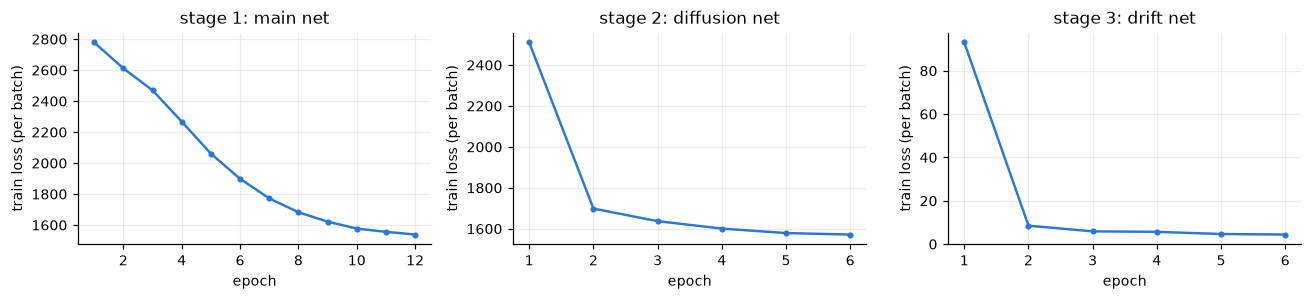

In [8]:
log_text = open(os.path.join(cfg.dload, cfg.save_name + '.log'), encoding='utf-8').read()
STAGE_NAMES = ['stage 1: main net', 'stage 2: diffusion net', 'stage 3: drift net']
stages, cur = [], None
for line in log_text.splitlines():
    if re.search(r'starting (Dt )?training', line):
        cur = {'name': STAGE_NAMES[len(stages) % 3], 'loss': []}
        stages.append(cur)
    m = re.search(r'epoch (\d+): loss ([-\d.eE+]+)', line)
    if m and cur is not None:
        cur['loss'].append(float(m.group(2)))
fig, axes = plt.subplots(1, len(stages), figsize=(4 * len(stages), 2.8))
for ax, st in zip(np.atleast_1d(axes), stages):
    ax.plot(np.arange(1, len(st['loss']) + 1), st['loss'], color=C_SPINN, marker='o', ms=3)
    ax.set_title(st['name']); ax.set_xlabel('epoch'); ax.set_ylabel('train loss (per batch)')
fig.tight_layout(); plt.show()

## 6. 在测试轨迹上推断

与 `run_SPINN.py --save_micro all` 相同：对每个“文件”（情景 × regular/head）依次调用 `transform`、`train_sigma(is_train=False)`、`train_velocity(is_train=False)`，然后按 `utils/export_results.py::load_microdynamics_tracks` 的方式截取预测段、反归一化，最后用帧号把 regular 与 head 两部分拼回完整轨迹。

得到每条测试轨迹、每一帧、每个维度上的：

| 变量 | 含义 |
|---|---|
| `v1` | SPINN 漂移估计（单步位移） |
| `s1` | SPINN 扩散估计（单步方差） |
| `v_raw`, `s_raw` | 平滑前的原始漂移 / 原始扩散 |
| `resid` | 一步预测残差 $x_{t+1}-y^{(1)}_t$ |

In [9]:
def spinn_infer(seg_x):
    """对一个“文件”的片段做完整 SPINN 推断，返回预测段 (B, L_PRED, D) 的各量（归一化单位）"""
    ds = DatasetTracks(seg_x, cfg, sample_rate=1.0)
    _, test_ds = generate_dataset_torch(ds, seed=cfg.seed, train_prob=1e-6)   # 保持顺序
    y0, y1, sigma_run, x_raw = transform(test_ds, model, cfg)
    s_ds, model_s = train_sigma(test_ds, model, cfg, is_train=False)
    _, s1, _, s_raw = transform(s_ds, model_s, cfg)
    v_ds, model_v = train_velocity(test_ds, model, cfg, is_train=False)
    _, v1, _, v_raw = transform(v_ds, model_v, cfg)
    tb = lambda a: a.transpose(1, 0, 2)                 # L x B x D -> B x L x D
    out = dict(v1=tb(v1)[:, -L_PRED:], s1=tb(s1)[:, -L_PRED:],
               v_raw=tb(v_raw)[:, L_ENC:], s_raw=tb(s_raw)[:, L_ENC:],
               resid=tb(sigma_run)[:, -L_PRED:])
    del s_ds, v_ds
    return out

KEYS = ['v1', 's1', 'v_raw', 's_raw', 'resid']
RES = {}
t0 = time.time()
for name in names:
    full = {k: np.full((N_TEST, T_LEN, 2), np.nan) for k in KEYS}
    last = np.zeros((N_TEST, T_LEN), bool)             # 每个预测段最后一帧（残差被补零）
    for kind in ['regular', 'head']:
        seg = SEGS[name]['test'][kind]
        o = spinn_infer(seg['x'])
        s = seg['norm'].reshape(1, 1, 2)
        o['v1'], o['v_raw'], o['resid'] = o['v1'] * s, o['v_raw'] * s, o['resid'] * s
        o['s1'], o['s_raw'] = o['s1'] * s ** 2, o['s_raw'] * s ** 2
        fr, tr = seg['frame'][:, L_ENC:], seg['track'][:, L_ENC:]
        for k in KEYS:
            full[k][tr, fr] = o[k]
        last[tr[:, -1], fr[:, -1]] = True
    full['last'] = last
    RES[name] = full
print(f'推断完成，用时 {time.time() - t0:.0f}s')

推断完成，用时 18s


## 7. 经典基线：单轨迹滑动窗口 OLS

为了判断 SPINN 的结果“好不好”，我们构造一个同样只使用**单条轨迹**信息的经典估计器：对每一帧 $n$，在以其为中心、宽 $W=50$ 帧（与编码长度相同）的窗口内做回归

$$
\Delta X_k = a + b\,X_k + \varepsilon_k ,\qquad k\in[n-W/2,\,n+W/2),
$$

漂移估计 $\hat v_n = \hat a+\hat b X_n$，方差估计为窗口内残差方差 $\hat s_n=\frac{1}{W-2}\sum\hat\varepsilon_k^2$。它和 SPINN 一样，不知道 $\mu$，也不知道参数何时变化；但注意它使用居中窗口（包含未来 25 帧），而 SPINN 主网络的一步预测是因果的（Transformer 因果 mask + 单向 GRU）。

In [10]:
W_BASE = 50

def rolling_ols(X):
    """X: (N,T,D) -> 漂移、方差估计 (N,T,D)，窗口居中"""
    dX = np.diff(X, axis=1, append=np.nan)
    Xk, dXk = X[:, :-1], dX[:, :-1]
    m = lambda z: uniform_filter1d(z, W_BASE, axis=1, mode='nearest')
    mx, my = m(Xk), m(dXk)
    vxx, vxy, vyy = m(Xk * Xk) - mx ** 2, m(Xk * dXk) - mx * my, m(dXk * dXk) - my ** 2
    b = vxy / vxx
    a = my - b * mx
    drift = np.concatenate([a + b * Xk, (a + b * Xk)[:, -1:]], axis=1)
    var = np.clip(vyy - b ** 2 * vxx, 1e-12, None) * W_BASE / (W_BASE - 2)
    var = np.concatenate([var, var[:, -1:]], axis=1)
    return drift, var

BASE = {}
for name in names:
    bd, bv = rolling_ols(DATA[name]['test']['X'])
    BASE[name] = dict(v=bd, s=bv)

## 8. 评估

### 8.1 评估指标

所有指标都只在**测试轨迹**上计算。

**(1) 漂移（逐点）**：对所有测试轨迹、帧、维度，比较估计的单步漂移位移 $\hat v$ 与真值 $v^\star=(\mu-X_n)(1-e^{-\theta_n\Delta})$：

$$
R^2_v = 1-\frac{\sum (\hat v - v^\star)^2}{\sum (v^\star-\overline{v^\star})^2},\qquad \rho_v = \mathrm{corr}(\hat v, v^\star).
$$

注意单步漂移的量级远小于单步噪声（信噪比约 $\sqrt{\theta\Delta/2}$），所以逐点 $R^2$ 天然不高，关键看与基线的相对比较。

**(2) 扩散（时间曲线）**：对同一时刻的所有测试轨迹与维度取平均，得到 $\hat\sigma^{\mathrm{eff}}_n=\sqrt{\langle\hat s_n\rangle/\Delta}$，与真值 $\sigma^{\mathrm{eff}}_n$ 比较平均相对误差

$$
\mathrm{MRE}_\sigma = \frac{1}{T}\sum_n\frac{|\hat\sigma^{\mathrm{eff}}_n-\sigma^{\mathrm{eff}}_n|}{\sigma^{\mathrm{eff}}_n}.
$$

同时报告逐点（单轨迹、单帧）扩散估计的中位相对误差 $\mathrm{med}\,|\hat s-s^\star|/s^\star$。

**(3) 从漂移中读出 $\theta_t$**：在每个时间窗（25 帧）内、每个维度上，把所有测试轨迹的漂移估计对位置做横截面回归 $\hat v = c + k X$，因为 $v^\star = (\mu-X)(1-e^{-\theta\Delta})$，有

$$
\hat\theta = -\frac{\ln(1+k)}{\Delta}.
$$

回归本身不使用真值 $\mu$（截距吸收了 $\mu$）。报告与真值 $\theta_t$ 的平均相对误差 $\mathrm{MRE}_\theta$。

**(4) 残差白化检验**：若 SPINN 正确分离了漂移和扩散，标准化残差 $z_n = (x_{n+1}-y^{(1)}_n)/\sqrt{s^{(1)}_n}$ 应近似 $\mathcal N(0,1)$ 且无自相关。报告 $\mathrm{std}(z)$ 与 lag-1 自相关。

In [11]:
BIN = 25
bins = np.arange(0, T_LEN + 1, BIN)
t_bin = (bins[:-1] + BIN / 2) * DT

def theta_from_drift(v, X):
    """每个时间窗内、每个维度分别做横截面回归 v = c + kX（x/y 的平衡位置不同，不能混在一起），返回 θ̂(t)"""
    out = np.full(len(bins) - 1, np.nan)
    for i in range(len(bins) - 1):
        sl, ks = slice(bins[i], bins[i + 1]), []
        for d in range(X.shape[2]):
            vv, xx = v[:, sl, d].ravel(), X[:, sl, d].ravel()
            ok = np.isfinite(vv) & np.isfinite(xx)
            ks.append(np.polyfit(xx[ok], vv[ok], 1)[0])
        out[i] = -np.log(np.clip(1 + np.mean(ks), 1e-6, None)) / DT
    return out

def r2(est, true):
    ok = np.isfinite(est) & np.isfinite(true)
    e, t = est[ok], true[ok]
    return 1 - np.sum((e - t) ** 2) / np.sum((t - t.mean()) ** 2), np.corrcoef(e, t)[0, 1]

rows, CURVES = [], {}
for name in names:
    tr, R, B = DATA[name]['test'], RES[name], BASE[name]
    X, v_true, s_true = tr['X'], tr['drift'], tr['var']
    th_true_bin = np.array([tr['theta'][bins[i]:bins[i + 1]].mean() for i in range(len(bins) - 1)])
    curves = dict(sig_true=tr['sigma_eff'], th_true=th_true_bin)
    for tag, v_est, s_est in [('SPINN', R['v1'], R['s1']), ('OLS 基线', B['v'], B['s'])]:
        R2v, rho_v = r2(v_est, v_true)
        sig_curve = np.sqrt(np.nanmean(s_est, axis=(0, 2)) / DT)
        th_curve = theta_from_drift(v_est, X)
        curves[tag] = dict(sig=sig_curve, th=th_curve)
        rows.append({'情景': name, '方法': tag,
                     '漂移 R²': R2v, '漂移 corr': rho_v,
                     'σ_eff 曲线 MRE': np.nanmean(np.abs(sig_curve - tr['sigma_eff']) / tr['sigma_eff']),
                     '逐点方差 中位相对误差': np.nanmedian(np.abs(s_est - s_true) / s_true),
                     'θ 曲线 MRE': np.nanmean(np.abs(th_curve - th_true_bin) / th_true_bin)})
    # 残差白化检验（仅 SPINN）
    z = R['resid'] / np.sqrt(np.clip(R['s1'], 1e-12, None))
    z[R['last']] = np.nan
    z0, z1 = z[:, :-1].ravel(), z[:, 1:].ravel()
    ok = np.isfinite(z0) & np.isfinite(z1)
    rows[-2].update({'std(z)': np.nanstd(z), 'lag-1 自相关(z)': np.corrcoef(z0[ok], z1[ok])[0, 1]})
    curves['z'] = z[np.isfinite(z)]
    CURVES[name] = curves

metrics = pd.DataFrame(rows).set_index(['情景', '方法'])
metrics.style.format('{:.3f}', na_rep='—')

### 8.2 汇总对比（6 个情景平均）

In [12]:
summary = metrics.groupby(level='方法').mean().T
summary['SPINN 更好?'] = [
    (summary.loc[i, 'SPINN'] > summary.loc[i, 'OLS 基线']) if ('R²' in i or 'corr' in i)
    else (summary.loc[i, 'SPINN'] < summary.loc[i, 'OLS 基线']) if ('MRE' in i or '误差' in i) else None
    for i in summary.index]
summary

方法,OLS 基线,SPINN,SPINN 更好?
漂移 R²,-0.224466,0.416696,True
漂移 corr,0.647137,0.649562,True
σ_eff 曲线 MRE,0.028001,0.055535,False
逐点方差 中位相对误差,0.144386,0.138853,True
θ 曲线 MRE,0.103854,0.518632,False
std(z),NaN,0.978344,None
lag-1 自相关(z),NaN,0.004566,None


### 8.3 扩散：$\sigma^{\mathrm{eff}}_t$ 的恢复

实线为真值，蓝色为 SPINN（测试轨迹平均），橙色为滑动窗口 OLS 基线。浅色带为 SPINN 在各轨迹间的 10%–90% 分位范围。

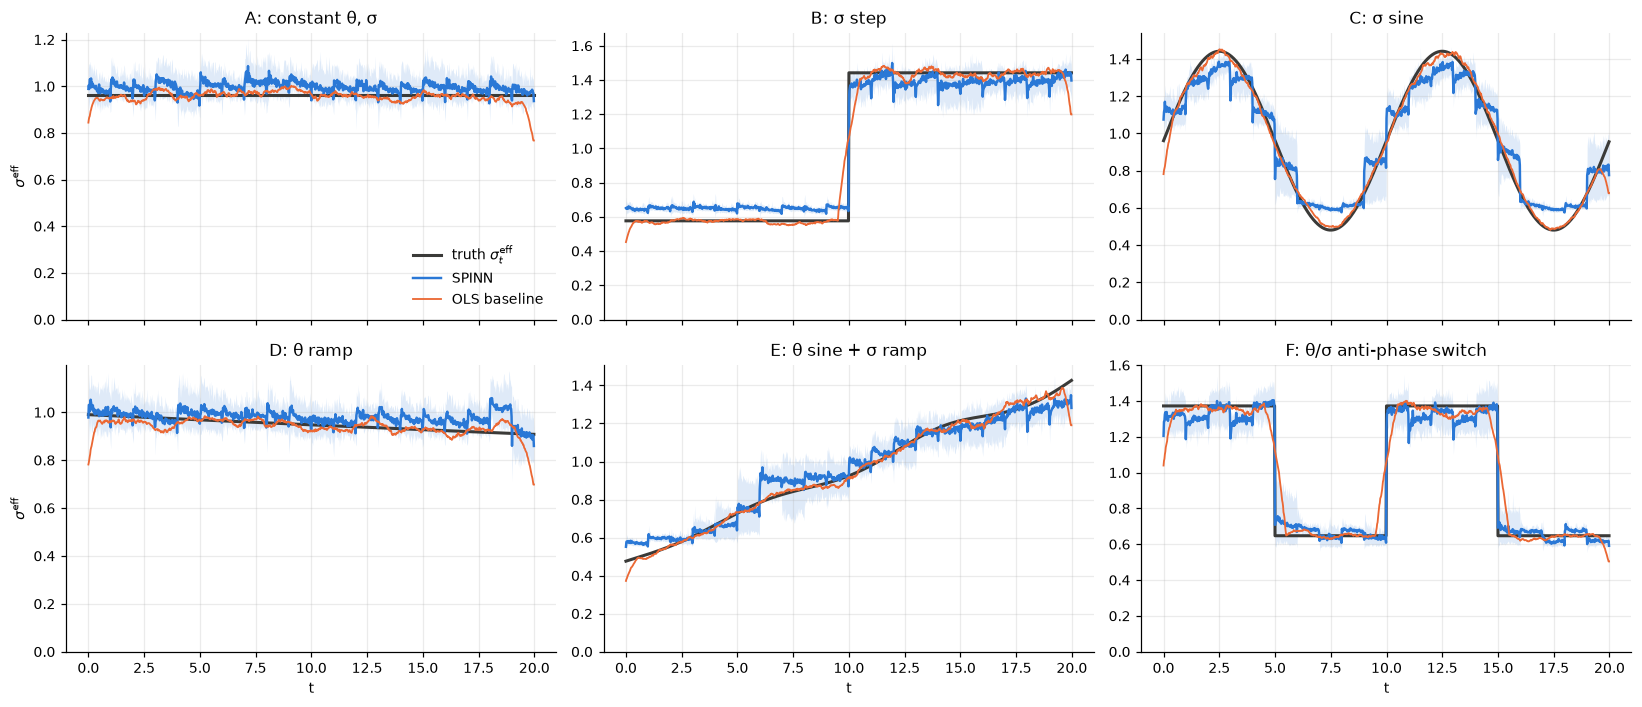

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6.5), sharex=True)
for ax, name in zip(axes.ravel(), names):
    c, R = CURVES[name], RES[name]
    per_track = np.sqrt(np.nanmean(R['s1'], axis=2) / DT)
    lo, hi = np.nanpercentile(per_track, [10, 90], axis=0)
    ax.fill_between(t_grid, lo, hi, color=C_SPINN, alpha=0.15, lw=0)
    ax.plot(t_grid, c['sig_true'], color=C_TRUE, lw=2, label=r'truth $\sigma^{\rm eff}_t$')
    ax.plot(t_grid, c['SPINN']['sig'], color=C_SPINN, label='SPINN')
    ax.plot(t_grid, c['OLS 基线']['sig'], color=C_BASE, lw=1.2, label='OLS baseline')
    ax.set_title(EN[name]); ax.set_ylim(bottom=0)
for ax in axes[1]: ax.set_xlabel('t')
for ax in axes[:, 0]: ax.set_ylabel(r'$\sigma^{\rm eff}$')
axes[0, 0].legend(loc='lower right')
fig.tight_layout(); plt.show()

### 8.4 漂移：从漂移估计中读出 $\theta_t$

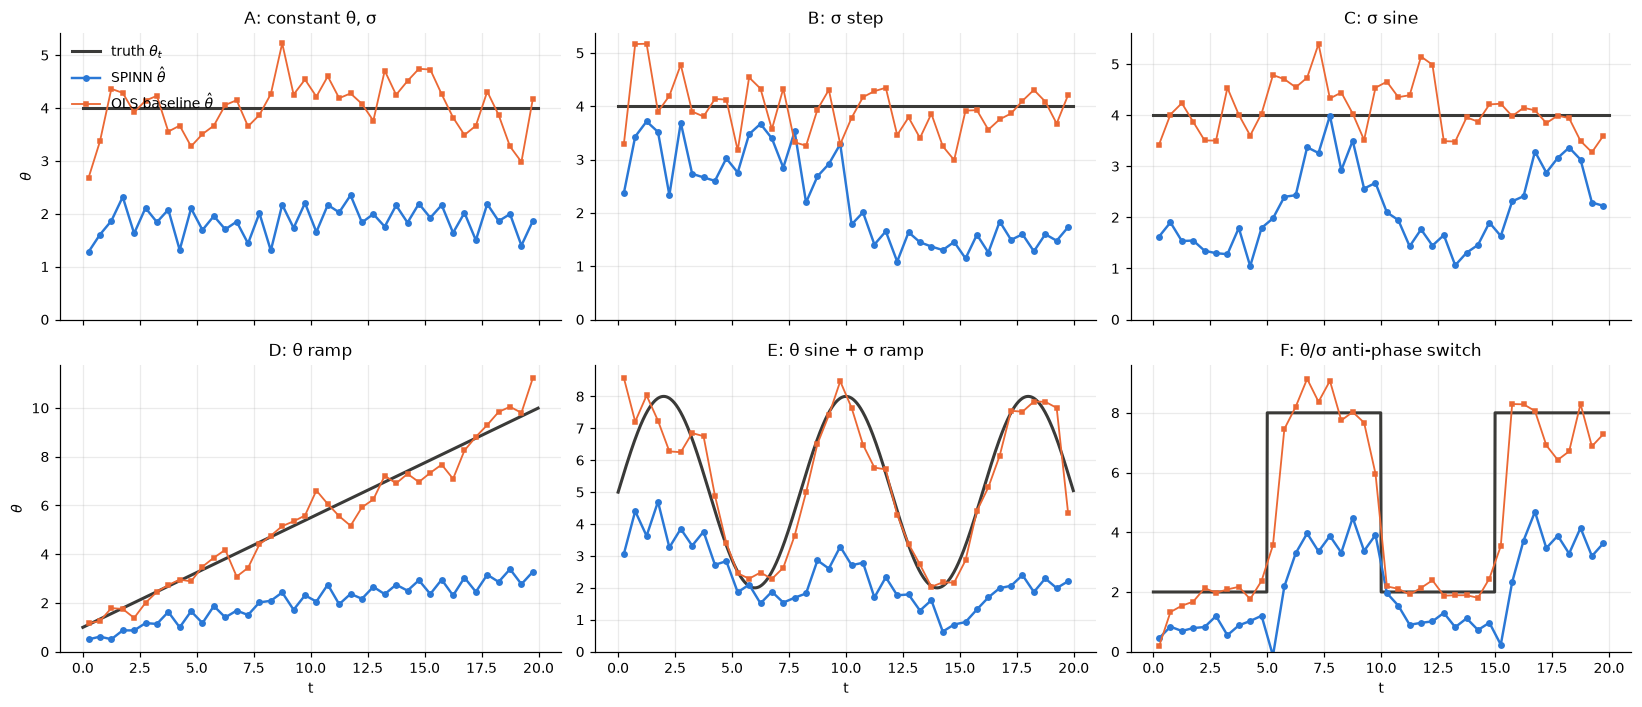

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6.5), sharex=True)
for ax, name in zip(axes.ravel(), names):
    c = CURVES[name]
    ax.plot(t_grid, DATA[name]['test']['theta'], color=C_TRUE, lw=2, label=r'truth $\theta_t$')
    ax.plot(t_bin, c['SPINN']['th'], color=C_SPINN, marker='o', ms=3.5, label=r'SPINN $\hat\theta$')
    ax.plot(t_bin, c['OLS 基线']['th'], color=C_BASE, marker='s', ms=3, lw=1.2, label=r'OLS baseline $\hat\theta$')
    ax.set_title(EN[name]); ax.set_ylim(bottom=0)
for ax in axes[1]: ax.set_xlabel('t')
for ax in axes[:, 0]: ax.set_ylabel(r'$\theta$')
axes[0, 0].legend(loc='upper left')
fig.tight_layout(); plt.show()

### 8.4b 逐帧（frame-wise）$\hat\theta_t$

8.4 按 25 帧一个时间窗做回归。这里改为**每一帧单独**做横截面回归：在第 $n$ 帧，对每个维度 $d$，用全部 $N_{\text{test}}=16$ 条测试轨迹拟合

$$
\hat v_{n,d}^{(i)} = c_{n,d} + k_{n,d}\,X_{n,d}^{(i)},\qquad i=1,\dots,N_{\text{test}},
$$

再对两个维度的斜率取平均，得到 $\hat\theta_n = -\ln(1+\bar k_n)/\Delta$。

每帧只有 $16\times2$ 个点，所以逐帧估计（散点）噪声较大。实线是 25 帧居中滚动中位数，只用来辅助观察趋势。

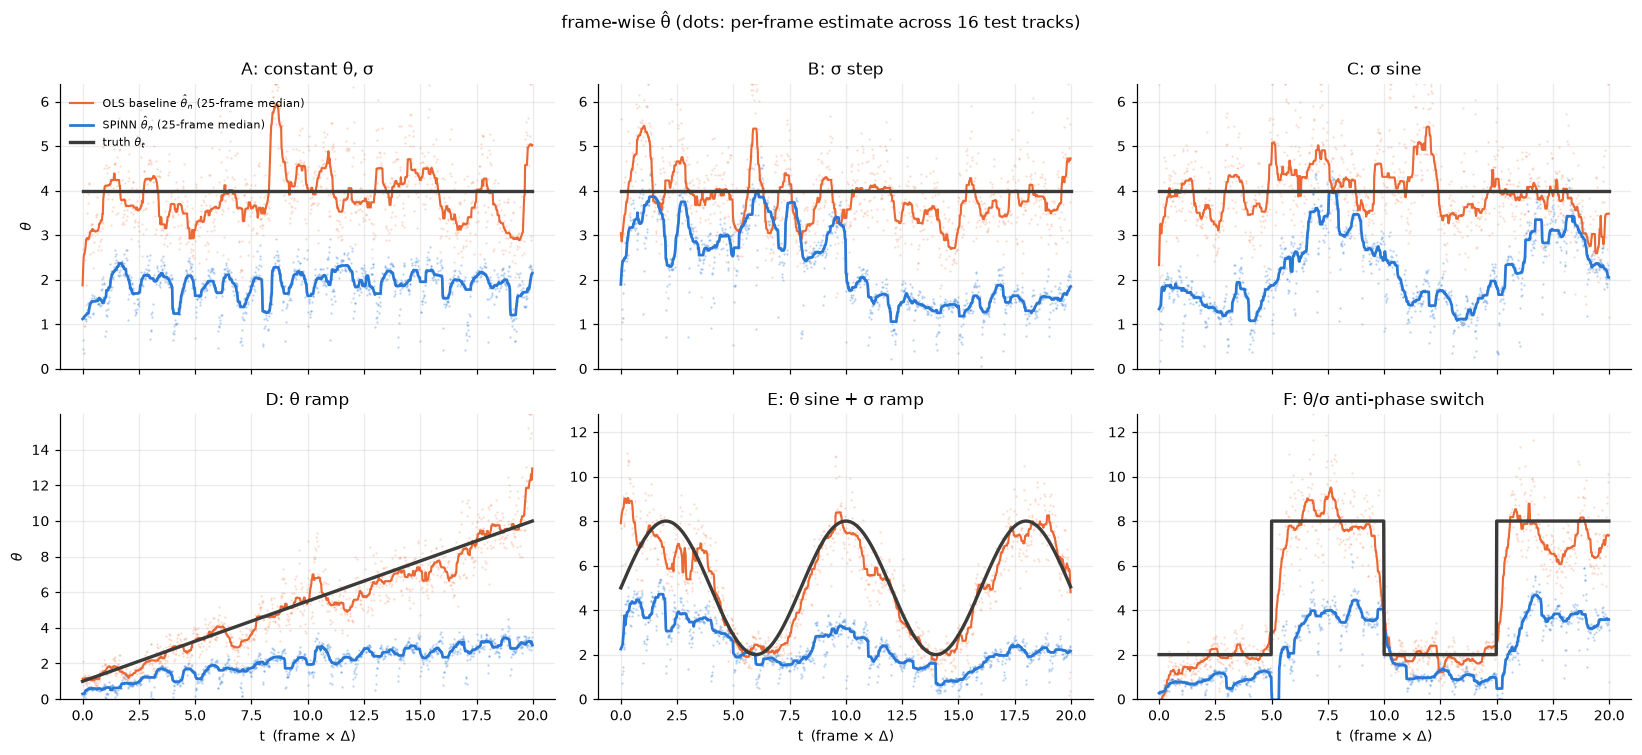

In [15]:
def theta_framewise(v, X):
    """逐帧横截面回归：每帧、每维对所有轨迹求斜率 k，两维平均后换算 θ̂"""
    xc = X - X.mean(axis=0, keepdims=True)
    vc = v - np.nanmean(v, axis=0, keepdims=True)
    k = (np.nansum(xc * vc, axis=0) / np.nansum(xc * xc, axis=0)).mean(axis=1)   # (T,)
    return -np.log(np.clip(1 + k, 1e-6, None)) / DT

smooth = lambda y: pd.Series(y).rolling(25, center=True, min_periods=5).median().values

TH_FW = {}
fig, axes = plt.subplots(2, 3, figsize=(15, 6.8), sharex=True)
for ax, name in zip(axes.ravel(), names):
    X = DATA[name]['test']['X']
    th_true = DATA[name]['test']['theta']
    th_sp, th_ols = theta_framewise(RES[name]['v1'], X), theta_framewise(BASE[name]['v'], X)
    TH_FW[name] = dict(truth=th_true, SPINN=th_sp, OLS=th_ols)
    ymax = 1.6 * th_true.max()
    ax.scatter(t_grid, np.clip(th_ols, 0, ymax), s=2, color=C_BASE, alpha=0.25, lw=0, rasterized=True)
    ax.scatter(t_grid, np.clip(th_sp, 0, ymax), s=2, color=C_SPINN, alpha=0.35, lw=0, rasterized=True)
    ax.plot(t_grid, smooth(th_ols), color=C_BASE, lw=1.4, label=r'OLS baseline $\hat\theta_n$ (25-frame median)')
    ax.plot(t_grid, smooth(th_sp), color=C_SPINN, lw=1.8, label=r'SPINN $\hat\theta_n$ (25-frame median)')
    ax.plot(t_grid, th_true, color=C_TRUE, lw=2.2, label=r'truth $\theta_t$')
    ax.set_title(EN[name]); ax.set_ylim(0, ymax)
for ax in axes[1]: ax.set_xlabel('t  (frame × Δ)')
for ax in axes[:, 0]: ax.set_ylabel(r'$\theta$')
axes[0, 0].legend(loc='upper left', fontsize=7.5)
fig.suptitle('frame-wise θ̂ (dots: per-frame estimate across 16 test tracks)', y=1.0)
fig.tight_layout(); plt.show()

# 逐帧误差汇总（用中位数，减少单帧离群值影响）
fw_rows = []
for name in names:
    d = TH_FW[name]
    for tag in ['SPINN', 'OLS']:
        rel = np.abs(d[tag] - d['truth']) / d['truth']
        fw_rows.append({'情景': name, '方法': 'SPINN' if tag == 'SPINN' else 'OLS 基线',
                        '逐帧相对误差 中位数': np.nanmedian(rel),
                        '平滑后相对误差 均值': np.nanmean(np.abs(smooth(d[tag]) - d['truth']) / d['truth']),
                        'corr(平滑 θ̂, θ)': np.corrcoef(np.nan_to_num(smooth(d[tag]), nan=np.nanmean(d[tag])), d['truth'])[0, 1]
                                             if d['truth'].std() > 0 else np.nan})
pd.DataFrame(fw_rows).set_index(['情景', '方法']).style.format('{:.3f}', na_rep='—（θ 为常数）')

**逐帧结果解读**（`SEED = 0`、`QUICK = True`）：

- **OLS 基线**的逐帧 $\hat\theta_n$ 围绕真值波动，中位相对误差约 13%–16%，能跟上 D 的线性上升、E 的正弦和 F 的切换。
- **SPINN** 的 $\hat\theta_n$ 整体偏低约一半。更值得注意的是，**它会随 $\sigma_t$ 反向变化**：
    - B：真实 $\theta$ 恒为 4，但 $\sigma$ 在 $t=10$ 跳高后，$\hat\theta$ 从约 3 掉到约 1.5；
    - C：$\hat\theta$ 的峰值出现在 $\sigma$ 的谷值处（$t\approx7.5,\,17.5$）；
    - E：$\sigma$ 线性增大，$\hat\theta$ 的正弦形状因此被一个下降趋势压扁；
    - F：$\theta$ 升高时 $\sigma$ 恰好降低，两种效应方向相同，所以切换看起来很清楚。这个情景对 $\theta$ 的“恢复”有一部分来自 $\sigma$ 的混淆。
- 只有 D（$\sigma$ 恒定）能干净地说明 SPINN 确实感知到了 $\theta$ 的变化：$\hat\theta$ 从约 0.5 单调升到约 3，与真值的相关系数为 0.94。
- 可能的原因：SPINN 的漂移输出在归一化单位下幅度大致固定，而真实漂移 $\theta(\mu-X)\Delta$ 的幅度与平稳标准差 $\sigma/\sqrt{2\theta}$ 成正比。噪声越大，漂移被收缩（shrink）得越厉害，折算出的 $\theta$ 就越小。
- 这说明在 OU 数据上，仅凭 SPINN 的漂移项估计绝对的 $\theta_t$ 并不可靠。如果要读 $\theta$，建议优先看相对变化，并与 $\sigma_t$ 的估计一起判断。

### 8.5 漂移逐点散点：估计 vs 真值

每个点是一条测试轨迹上某一帧某一维的单步漂移位移。黑色虚线为 $y=x$。

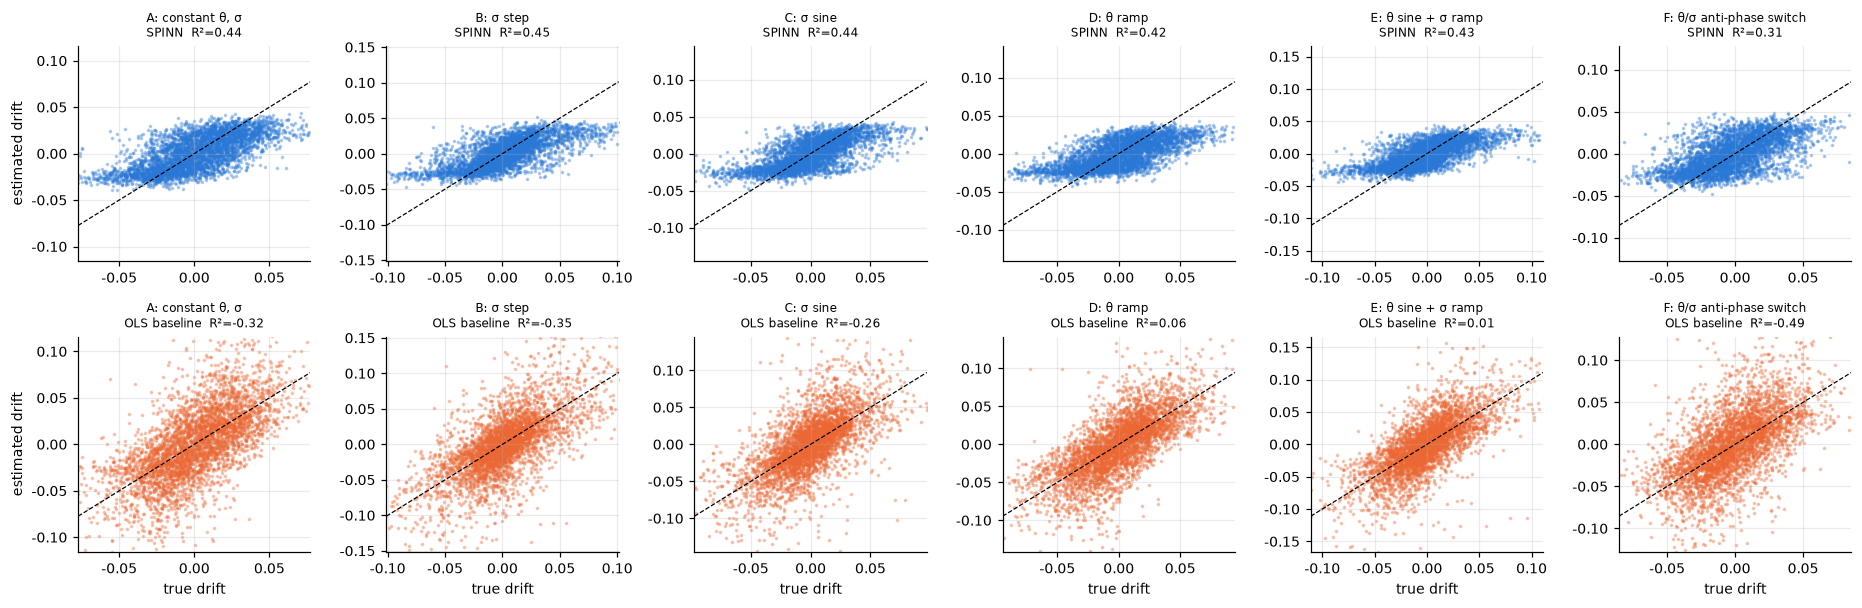

In [16]:
fig, axes = plt.subplots(2, 6, figsize=(17, 5.6))
for j, name in enumerate(names):
    v_true = DATA[name]['test']['drift'].ravel()
    lim = np.nanpercentile(np.abs(v_true), 99.5)
    for i, (tag, est, col) in enumerate([('SPINN', RES[name]['v1'], C_SPINN), ('OLS 基线', BASE[name]['v'], C_BASE)]):
        ax = axes[i, j]
        idx = np.random.default_rng(0).choice(v_true.size, 4000, replace=False)
        ax.scatter(v_true[idx], est.ravel()[idx], s=2, alpha=0.3, color=col, rasterized=True)
        ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8)
        ax.set_xlim(-lim, lim); ax.set_ylim(-1.5 * lim, 1.5 * lim)
        ax.set_title(f'{EN[name]}\n{"SPINN" if tag == "SPINN" else "OLS baseline"}  R²={metrics.loc[(name, tag), "漂移 R²"]:.2f}', fontsize=8)
        if j == 0: ax.set_ylabel('estimated drift')
        if i == 1: ax.set_xlabel('true drift')
fig.tight_layout(); plt.show()

### 8.6 单条轨迹的逐帧分解

取每个情景的第一条测试轨迹（$x$ 分量），展示 SPINN 的漂移 $v^{(1)}_t$、扩散 $s^{(1)}_t$ 以及平滑前的原始量，对照真值。

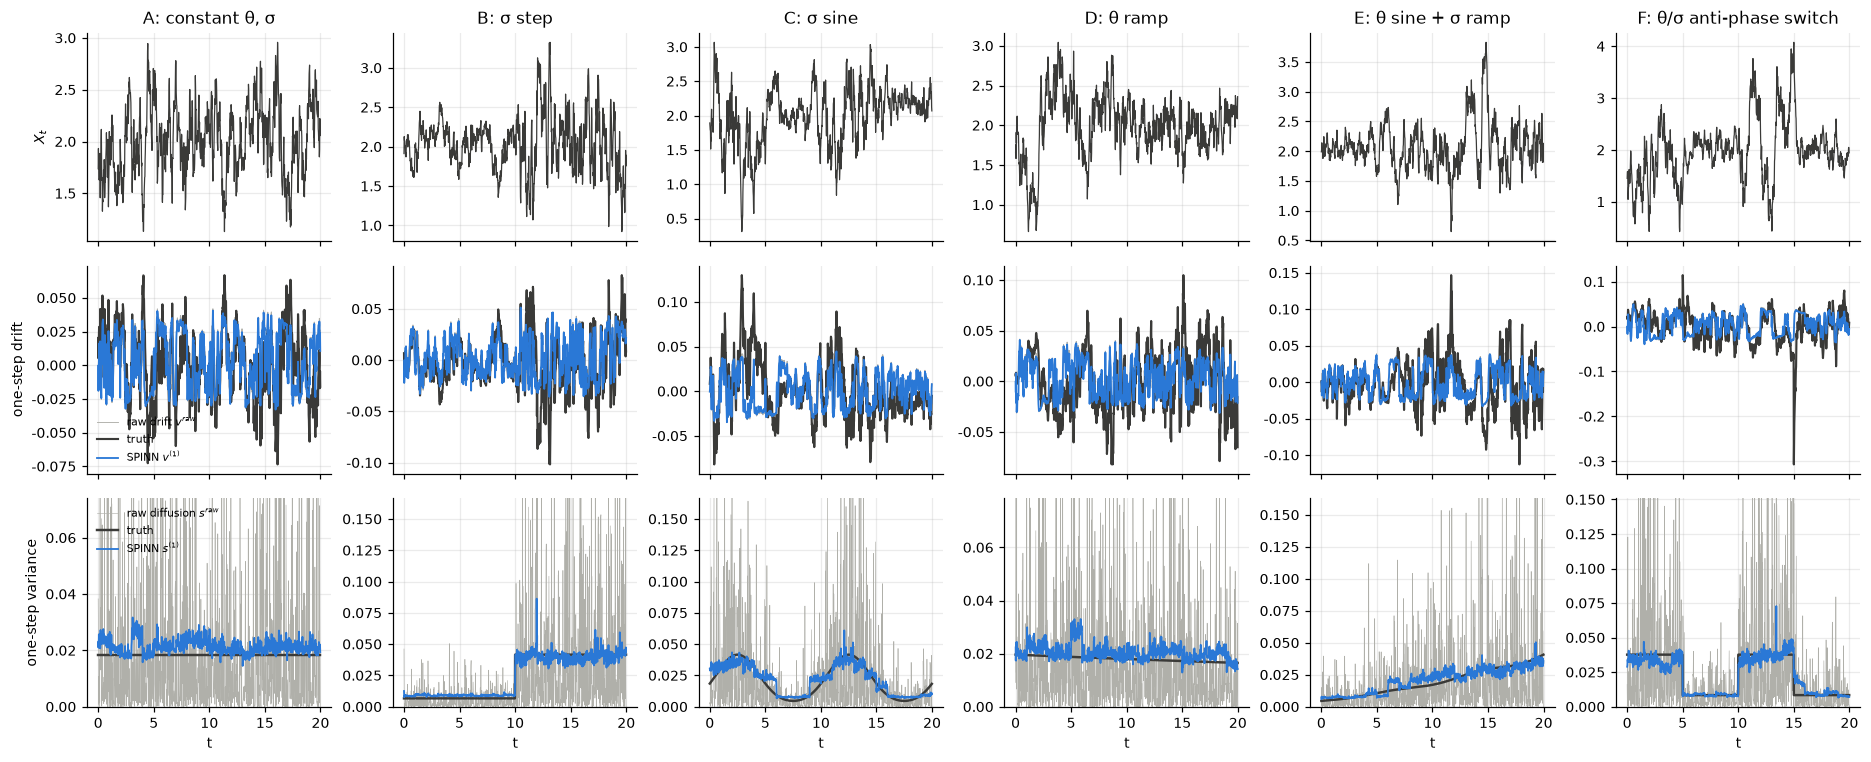

In [17]:
fig, axes = plt.subplots(3, 6, figsize=(17, 7), sharex=True)
for j, name in enumerate(names):
    tr, R = DATA[name]['test'], RES[name]
    k = 0
    axes[0, j].plot(t_grid, tr['X'][k, :, 0], color=C_TRUE, lw=0.8)
    axes[0, j].set_title(EN[name])
    axes[1, j].plot(t_grid, R['v_raw'][k, :, 0], color='#b0b0aa', lw=0.6, label='raw drift $v^{raw}$')
    axes[1, j].plot(t_grid, tr['drift'][k, :, 0], color=C_TRUE, lw=1.4, label='truth')
    axes[1, j].plot(t_grid, R['v1'][k, :, 0], color=C_SPINN, lw=1.2, label='SPINN $v^{(1)}$')
    axes[2, j].plot(t_grid, R['s_raw'][k, :, 0], color='#b0b0aa', lw=0.4, label='raw diffusion $s^{raw}$')
    axes[2, j].plot(t_grid, tr['var'][k, :, 0], color=C_TRUE, lw=1.6, label='truth')
    axes[2, j].plot(t_grid, R['s1'][k, :, 0], color=C_SPINN, lw=1.2, label='SPINN $s^{(1)}$')
    axes[2, j].set_ylim(0, 4 * tr['var'].max())
    axes[2, j].set_xlabel('t')
axes[0, 0].set_ylabel('$X_t$'); axes[1, 0].set_ylabel('one-step drift'); axes[2, 0].set_ylabel('one-step variance')
axes[1, 0].legend(fontsize=7, loc='lower left'); axes[2, 0].legend(fontsize=7, loc='upper left')
fig.tight_layout(); plt.show()

### 8.7 标准化残差检验

若分解正确，$z=(x_{t+1}-y^{(1)}_t)/\sqrt{s^{(1)}_t}$ 的分布应与标准正态（黑线）重合。

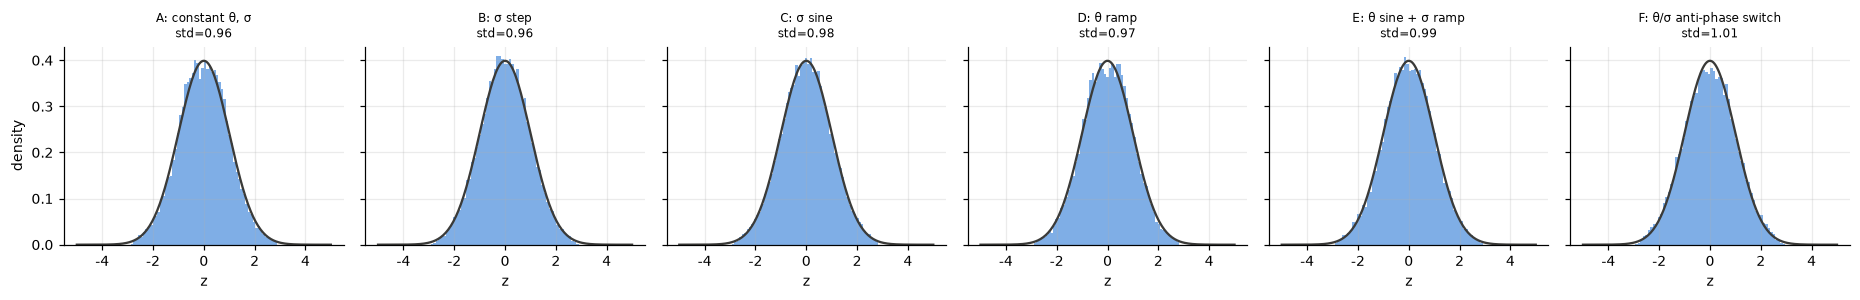

In [18]:
from scipy.stats import norm as _norm
fig, axes = plt.subplots(1, 6, figsize=(17, 2.8), sharey=True)
grid = np.linspace(-5, 5, 200)
for ax, name in zip(axes, names):
    z = CURVES[name]['z']
    ax.hist(np.clip(z, -5, 5), bins=60, density=True, color=C_SPINN, alpha=0.6)
    ax.plot(grid, _norm.pdf(grid), color=C_TRUE, lw=1.5)
    ax.set_title(f'{EN[name]}\nstd={np.std(z):.2f}', fontsize=8); ax.set_xlabel('z')
axes[0].set_ylabel('density')
fig.tight_layout(); plt.show()

## 9. 结果解读与进一步实验

以下是在 4 核 CPU、`QUICK = True`、`SEED = 0` 下得到的典型结果（不同机器/随机种子会有小幅波动）：

| 指标（6 个情景平均） | SPINN | OLS 基线 |
|---|---|---|
| 漂移 $R^2$（逐点） | ≈ 0.42 | ≈ −0.22 |
| 漂移相关系数 | ≈ 0.65 | ≈ 0.65 |
| $\sigma^{\rm eff}$ 曲线 MRE | ≈ 5.6% | ≈ 2.8% |
| 逐点方差中位相对误差 | ≈ 0.14 | ≈ 0.14 |
| $\theta$ 曲线 MRE | ≈ 0.52 | ≈ 0.10 |
| 标准化残差 std / lag-1 自相关 | ≈ 0.98 / ≈ 0.00 | — |

- **扩散项恢复得很好**：SPINN 能准确跟踪 $\sigma_t$ 的阶跃（B、F）、正弦（C）和线性变化（E），标准化残差接近 $\mathcal N(0,1)$ 且无自相关，说明漂移/扩散分解在二阶矩意义下是自洽的。曲线上每隔 50 帧（1 个时间单位）有小的锯齿，来自片段拼接（regular / head 片段交替覆盖）。
- **漂移项“形状对、幅度偏小”**：逐点 $R^2$ 明显优于基线（基线在单轨迹 50 帧窗口内估计斜率噪声很大），但从漂移中读出的 $\hat\theta$ 系统性偏低（约为真值的一半）。原因：单步漂移的信噪比只有 $\sqrt{\theta\Delta/2}\approx0.1\sim0.3$，神经网络在不确定时倾向于收缩（shrinkage）预测；另外 `DatasetTracks` 把每个片段平移到编码段末点，网络只能从 50 帧历史中推断平衡位置 $\mu$。好的一面是 $\hat\theta$ 的**相对时间变化**（D 的线性上升、E 的正弦、F 的切换）是被捕捉到的，逐帧图（8.4b）上也能看到。
- **公平性说明**：OLS 基线使用**居中**窗口（用到了未来 25 帧），而 SPINN 主网络的一步预测是因果的，因此基线在平滑变化的 $\sigma_t$ 上略占优势。
- **可调节的实验**：
    - 设置 `QUICK = False` 使用仓库默认超参数与 epoch 数（强烈建议 GPU），通常能进一步缩小漂移幅度偏差；
    - 调大 `N_TRAIN`、`T_LEN`，或增大 `DT`（提高 $\theta\Delta$，从而提高漂移信噪比）；
    - 在 `SCENARIOS` 中加入新的 $\theta_t,\sigma_t$ 组合，例如 $\sigma_t$ 的周期性脉冲，或 $\theta_t\to0$ 时退化为布朗运动；
    - 修改 `cfg.noise_adding` 观察定位噪声对分解的影响。